MultiClass Classification using Tensorflow
- This notebook demonstrates how to perform multi-class classification using a neural network with TensorFlow.
- The dataset used is the MNIST dataset which contains images of handwritten digits.
- The neural network will be trained on the training data and then tested on the test data.
- The model will be using the Adam optimizer and SparseCategoricalCrossentropy loss function.
- The test data will be visualized to show the model's predictions.

In [20]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.losses import SparseCategoricalCrossentropy

In [21]:
input_data = pd.read_csv('/kaggle/input/digit-recognizer/train.csv') # if not using kaggle use "/data/digit-recognizer-data/train.csv"
input_data.head()

data = input_data.to_numpy()

# Data Visualization
Visualization of the first 10 images in the dataset.

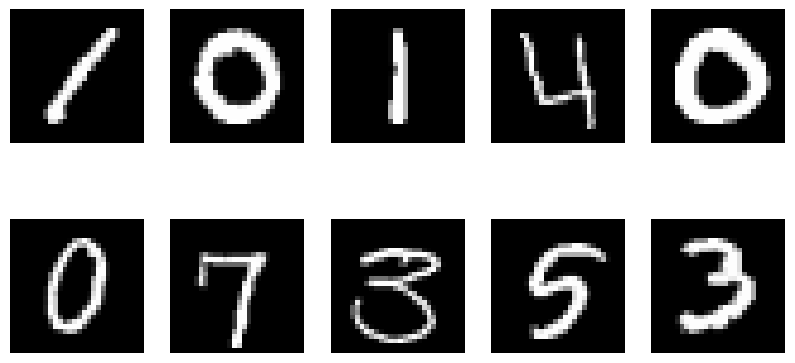

In [22]:
# get x by ignoring the first column which contains the labels
x = data[:, 1:]
# get y by selecting the first column which contains the labels
y = data[:, 0]

# Reshape each row to a 28x28 image
x_images = x.reshape(-1, 28, 28)

# Set up a grid for displaying the first 10 images (e.g., 2 rows and 5 columns)
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 5))

# Plot the first 10 images
for i, ax in enumerate(axes.flat):
    ax.imshow(x_images[i], cmap='gray')  # Show image in grayscale
    ax.axis('off')  # Hide axis for a cleaner look

plt.show()

# Prepare Model
Create a neural network model with 3 layers:
- Input layer with 784 neurons (28x28 image flattened)
- Hidden layer with 25 neurons and ReLU activation function
- Hidden layer with 15 neurons and ReLU activation function
- Output layer with 10 neurons (one for each digit) and Softmax activation function

In [23]:
model = Sequential([
    Dense(25, activation='relu'),
    Dense(15, activation='relu'),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss=SparseCategoricalCrossentropy())

# Train Model
- Train the model on the training data (x, y) for 10 epochs.

In [24]:
model.fit(x, y, epochs=10)
model.summary()

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 4.9868
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.0615
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.7255
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.5990
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4943
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.4307
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4043
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3719
Epoch 9/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3186
Epoch 10/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3123


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 25)             │        19,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,527 (236.44 KB)

 Trainable params: 20,175 (78.81 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 40,352 (157.63 KB)

# Test Model
- Use the trained model to predict the test data.
- Visualize the first 100 predictions with the actual target values.
- The title of each image will show the predicted value.

In [25]:
def GetOutput(input):
    predictions = model.predict(input)
    yhat = np.argmax(predictions, axis=1).reshape(-1, 1)
    return yhat

875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


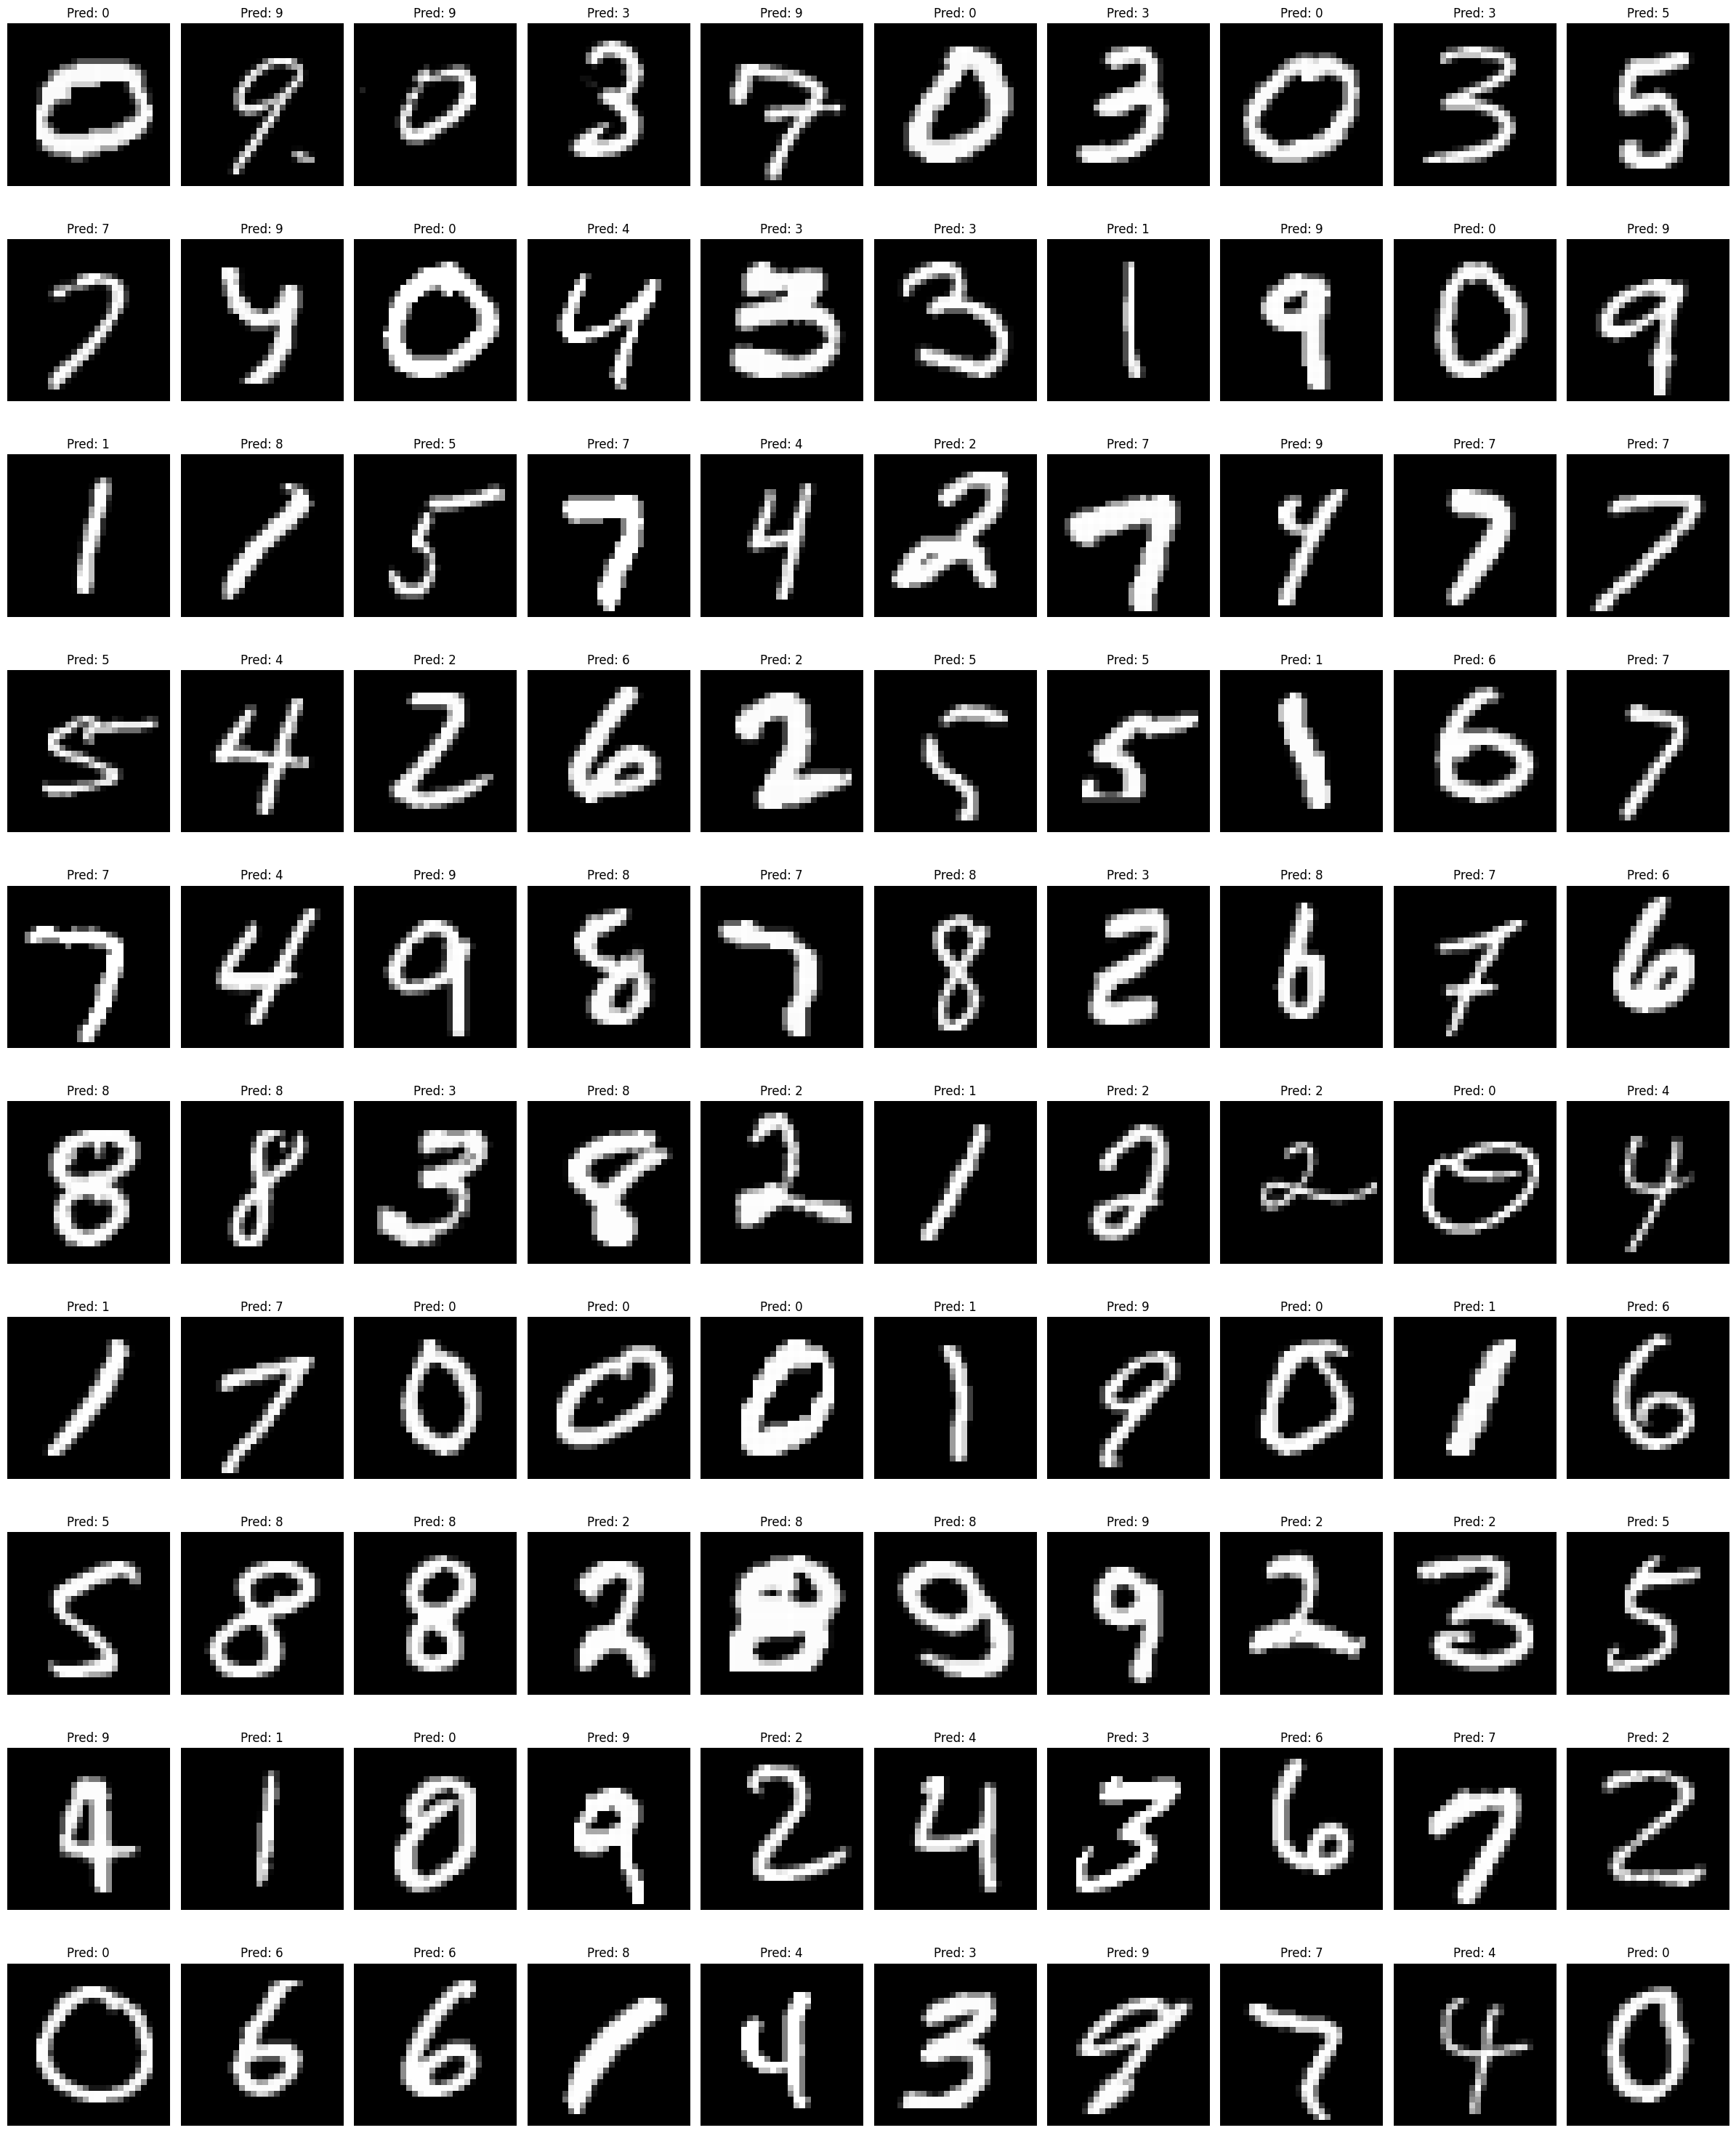

In [26]:
testData = pd.read_csv('/kaggle/input/digit-recognizer/test.csv')
testData = testData.to_numpy()


x_test = testData[1:]

yhat = GetOutput(x_test)

# Reshape x_test images to 28x28 for visualization
x_images = x_test.reshape(-1, 28, 28)

# Set up the plot grid (e.g., 2 rows and 5 columns)
fig, axes = plt.subplots(nrows=10, ncols=10, figsize=(24, 30))

# Plot the first 10 images with target vs prediction in titles
for i, ax in enumerate(axes.flat):
    ax.imshow(x_images[i], cmap='gray')  # Show the image in grayscale
    ax.axis('off')  # Hide axes
    # Set title to show target vs prediction
    ax.set_title(f"Pred: {int(yhat[i][0])}")  # Extract first element for prediction

plt.tight_layout()
plt.show()